# Signal Generator — Parameter Exploration

How each constructor parameter of **KernelSynth** and **TSMixup** shapes the generated signal.
Two helpers (`sweep`, `inject_compare`) do all the plotting, so every experiment below is one line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, '/mnt/user-data/uploads')
from generators.kernelsynth_generator import KernelSynthGenerator
from generators.tsmixup_generator import TSMixupGenerator


plt.style.use('seaborn-v0_8-darkgrid')
SEED = 42

In [2]:
def sweep(make_gen, values, title, label, color='steelblue', time_axis=False):
    """Plot one generated signal per value in a single row."""
    fig, axes = plt.subplots(1, len(values), figsize=(5 * len(values), 3.6), squeeze=False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, v in zip(axes[0], values):
        gen = make_gen(v)
        sig = gen.generate()
        x = np.arange(len(sig)) / gen.fs if time_axis else np.arange(len(sig))
        ax.plot(x, sig, lw=0.8, color=color)
        ax.set_title(f'{label} = {v}', fontsize=11)
        ax.set_xlabel('Time (s)' if time_axis else 'Samples')
        tag = f'dur={x[-1]:.1f}s' if time_axis else f'std={sig.std():.2f}'
        ax.annotate(tag, xy=(.97, .97), xycoords='axes fraction', ha='right', va='top',
                    fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
    axes[0][0].set_ylabel('Amplitude')
    plt.tight_layout(); plt.show()


def inject_compare(GenCls, base_kw, values, mode, title, P=16, amp=1.0):
    """Each row = same seed: base (faded) vs cpp-injected vs hz-injected sinusoid."""
    fig, axes = plt.subplots(len(values), 2, figsize=(13, 3.2 * len(values)), squeeze=False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for r, v in enumerate(values):
        base = GenCls(**base_kw, P=P, seed=SEED).generate()
        inj = GenCls(**base_kw, P=P, seed=SEED,
                     inject={'mode': mode, 'value': v, 'amplitude': amp, 'phase': 0.0}).generate()
        period = (P / v) if mode == 'cpp' else (base_kw.get('fs', 1.0) / v)
        for c, (sig, col, lbl) in enumerate([(base, 'steelblue', 'base (no inject)'),
                                             (inj, 'purple', f'{mode}={v} → period {period:.0f} smp')]):
            ax = axes[r][c]
            if c == 1:
                ax.plot(base, lw=0.5, color='steelblue', alpha=0.5) 
            ax.plot(sig, lw=0.8, color=col)
            ax.set_title(lbl, fontsize=10); ax.set_xlabel('Samples')
            if c == 0: ax.set_ylabel('Amplitude')
    plt.tight_layout(); plt.show()


## KernelSynth

Samples from a composite Gaussian-Process prior built from a random mix of base kernels
(RBF, Periodic, Linear, …). **Sampling-rate dependent**: `fs` sets the time axis, so periodic
kernels and Hz-injection change with it.

**J** — number of kernels combined. More kernels → richer / more structured covariance.

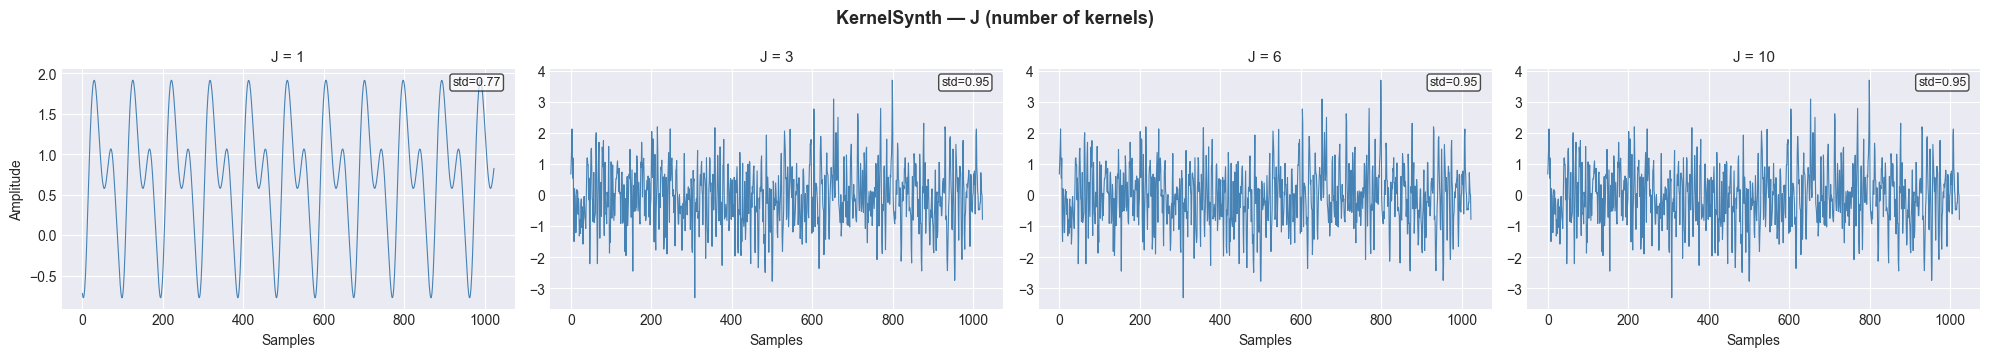

In [3]:
sweep(lambda J: KernelSynthGenerator(J=J, l_syn=1024, jitter=1e-6, fs=1.0, seed=SEED),
      [1, 3, 6, 10], 'KernelSynth — J (number of kernels)', 'J')

**l_syn** — signal length in samples. Only changes how much of the same process you see.

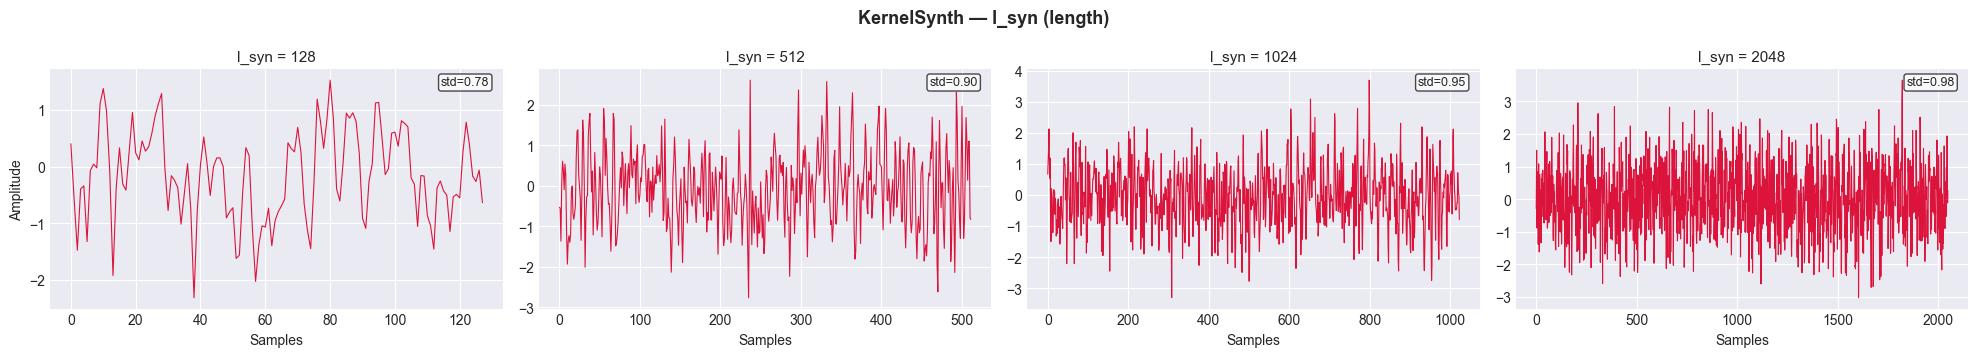

In [4]:
sweep(lambda L: KernelSynthGenerator(J=5, l_syn=L, jitter=1e-6, fs=1.0, seed=SEED),
      [128, 512, 1024, 2048], 'KernelSynth — l_syn (length)', 'l_syn', color='crimson')

**jitter** — added to the covariance diagonal for numerical stability. Too small → possible `LinAlgError`; too large → injected white noise.

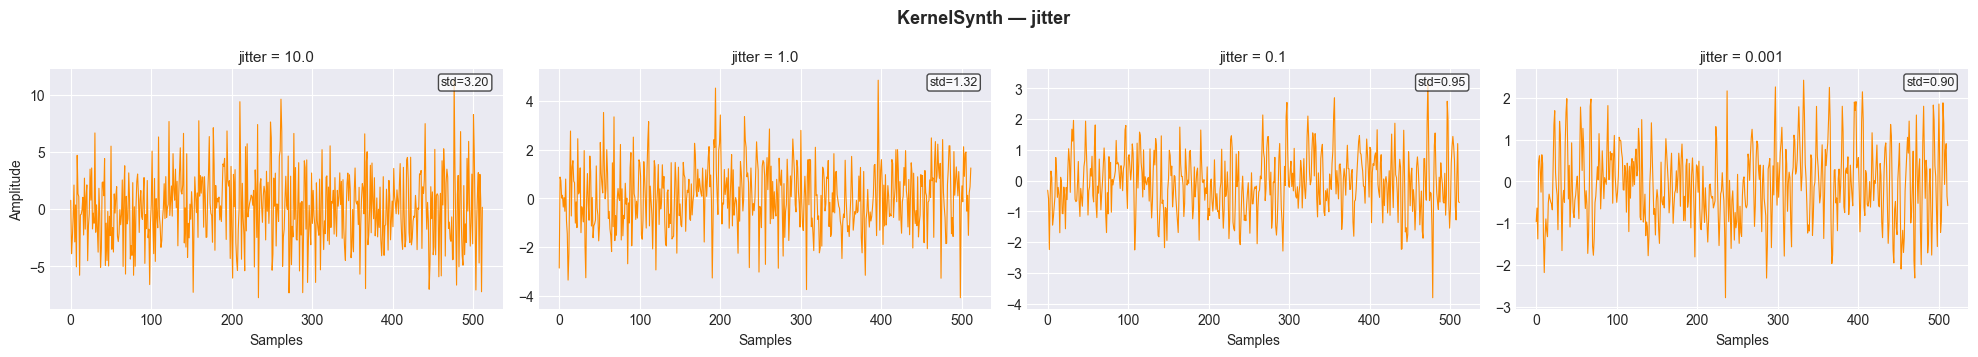

In [5]:
sweep(lambda j: KernelSynthGenerator(J=5, l_syn=512, jitter=j, fs=1.0, seed=SEED),
      [1e1, 1e0, 1e-1, 1e-3], 'KernelSynth — jitter', 'jitter', color='darkorange')

**fs** — sampling frequency. Rescales the time axis (duration = l_syn / fs).

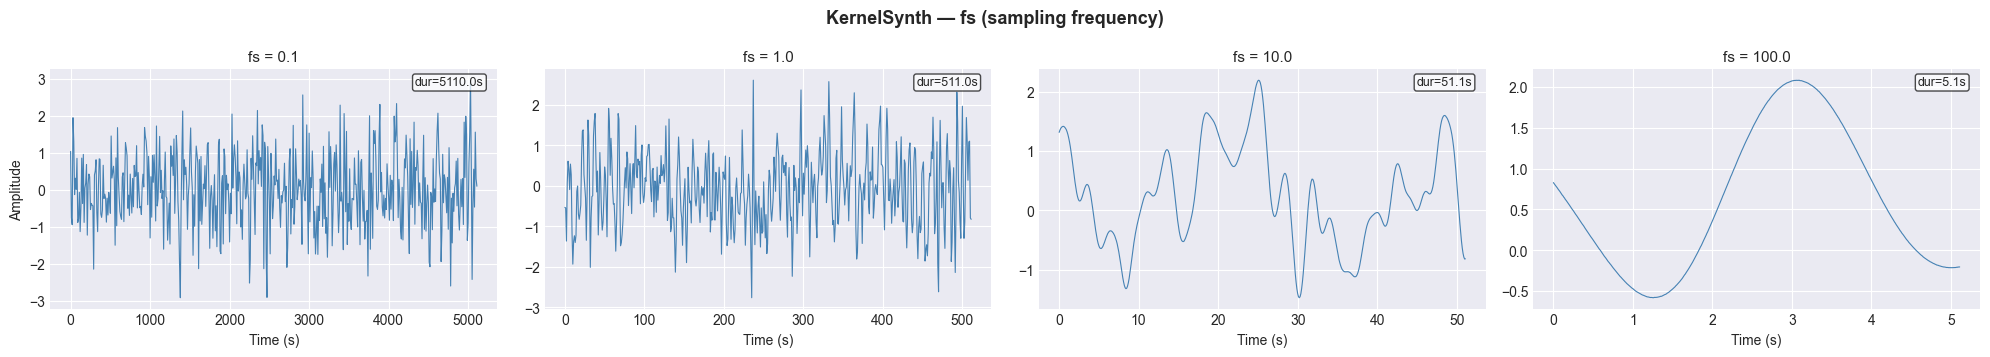

In [6]:
sweep(lambda fs: KernelSynthGenerator(J=5, l_syn=512, jitter=1e-6, fs=fs, seed=SEED),
      [0.1, 1.0, 10.0, 100.0], 'KernelSynth — fs (sampling frequency)', 'fs', color='steelblue', time_axis=True)

### Injection
A deterministic sinusoid is added on top of the unit-std background.
- **cpp** (cycles-per-patch): period = `P / cpp` samples — tied to tokenisation.
- **hz**: period = `fs / f` seconds — tied to sampling.

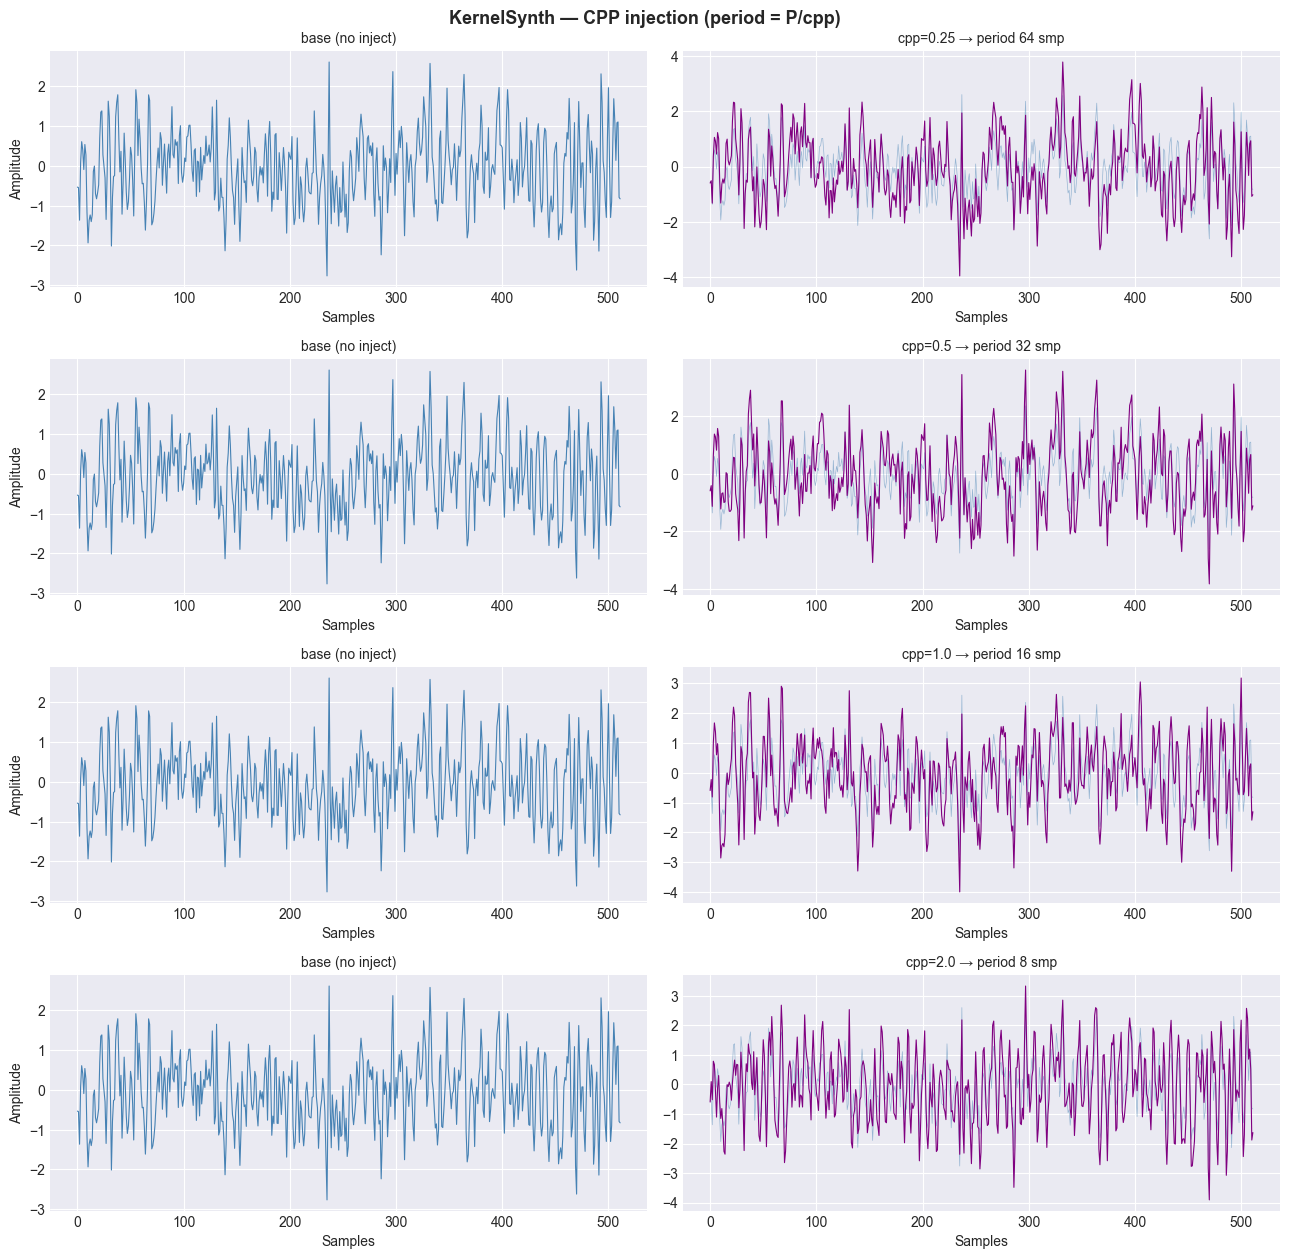

In [7]:
inject_compare(KernelSynthGenerator, dict(J=5, l_syn=512, jitter=1e-6, fs=1.0),
               [0.25, 0.5, 1.0, 2.0], 'cpp',
               'KernelSynth — CPP injection (period = P/cpp)')

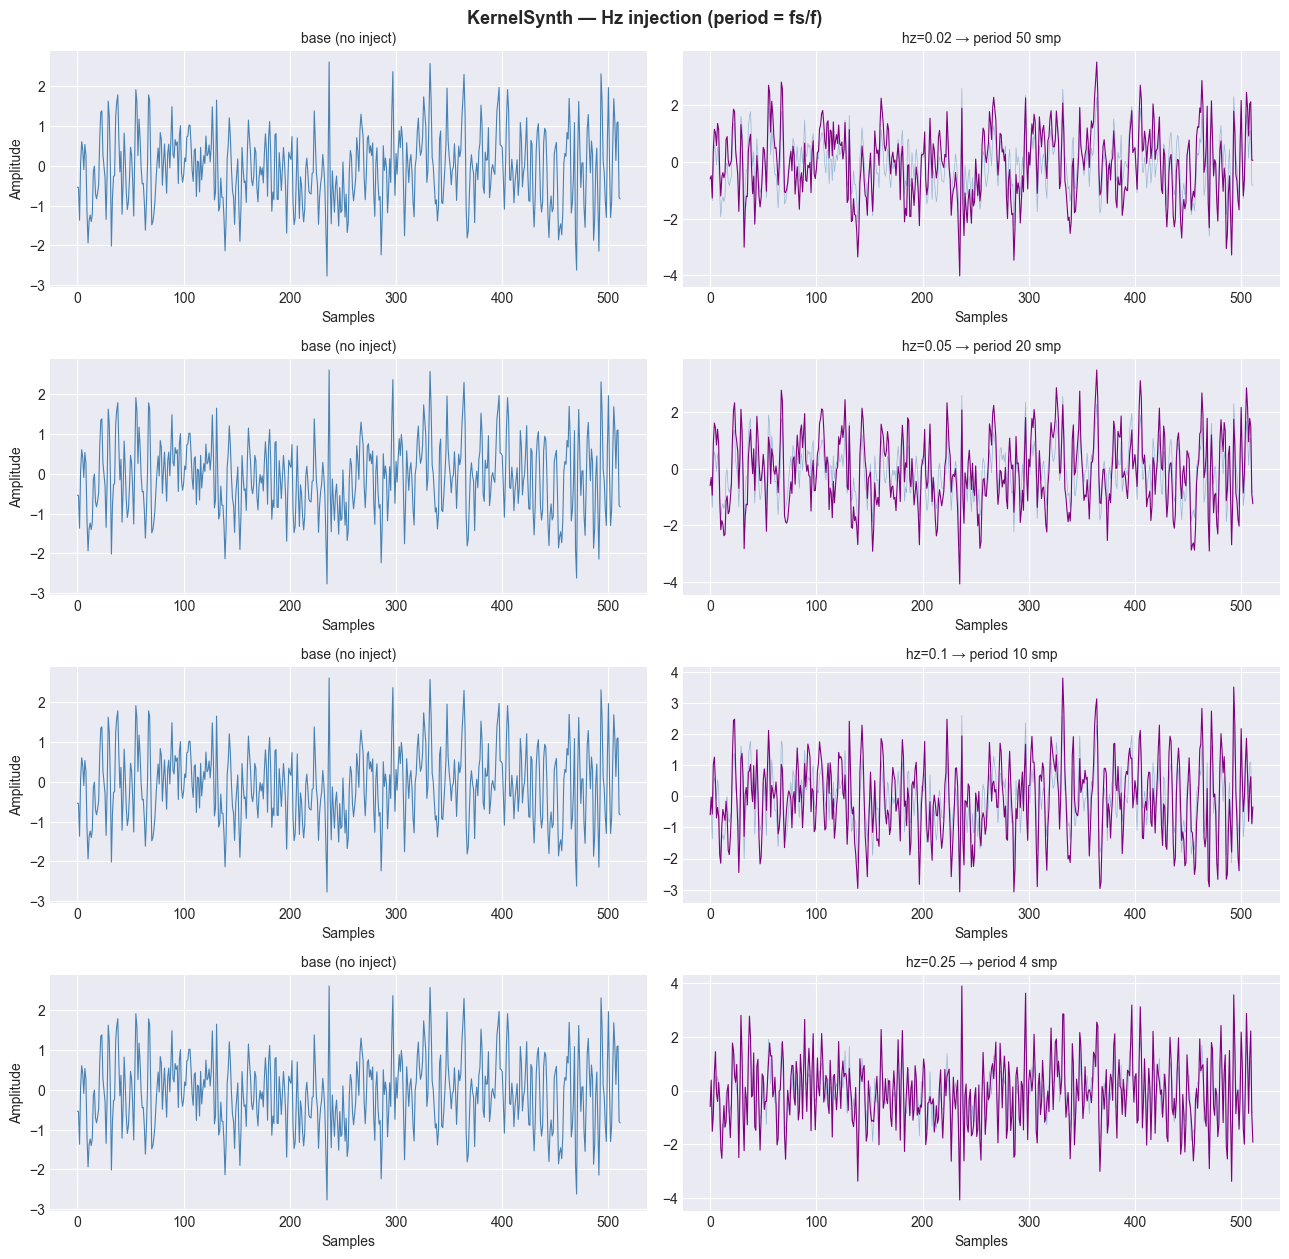

In [8]:
inject_compare(KernelSynthGenerator, dict(J=5, l_syn=512, jitter=1e-6, fs=1.0),
               [0.02, 0.05, 0.1, 0.25], 'hz',
               'KernelSynth — Hz injection (period = fs/f)')

## TSMixup

Mixes `k` mean-scaled subsequences with Dirichlet weights. **Sampling-rate agnostic**: it works
in sample space, so `fs` does *not* change the base signal — it only affects Hz-mode injection.

**K** — max subsequences mixed (random 1…K). Higher K → smoother, more averaged signal.

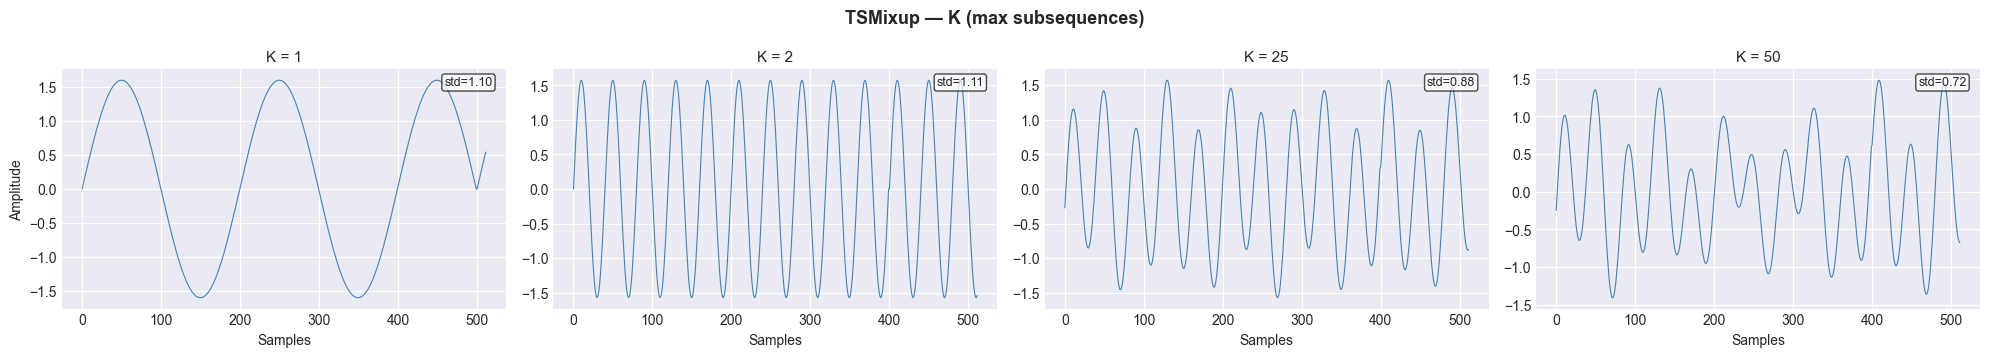

In [9]:
sweep(lambda K: TSMixupGenerator(K=K, alpha=1.5, l_min=512, l_max=512, seed=SEED),
      [1, 2, 25, 50], 'TSMixup — K (max subsequences)', 'K')

**alpha** — Dirichlet concentration. Low → one subsequence dominates; high → even blend.

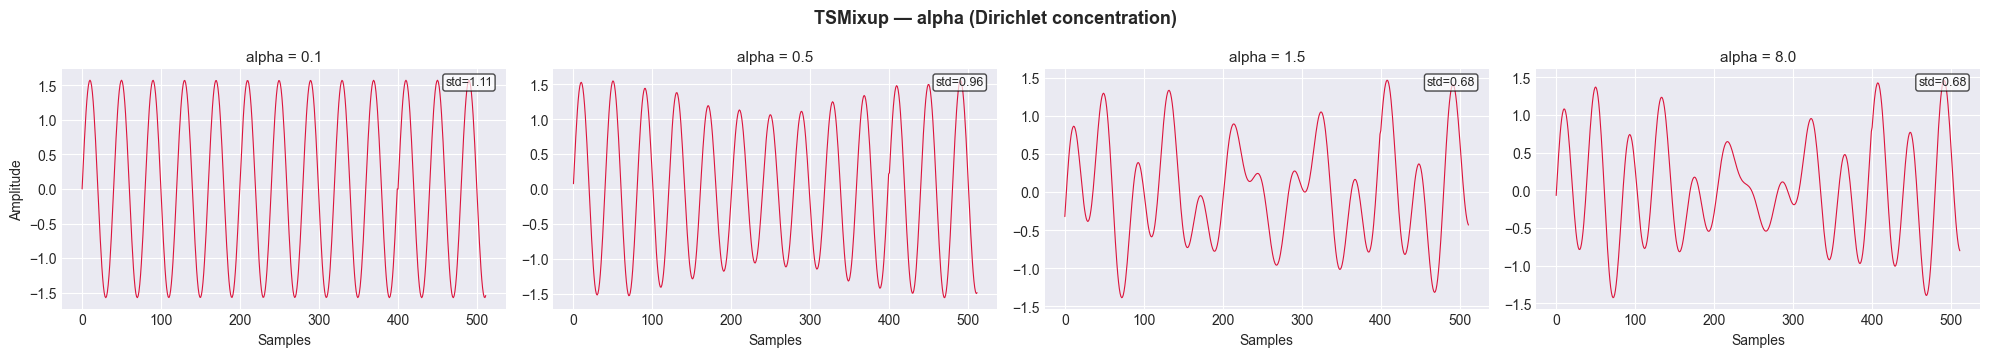

In [10]:
sweep(lambda a: TSMixupGenerator(K=40, alpha=a, l_min=512, l_max=512, seed=SEED),
      [0.1, 0.5, 1.5, 8.0], 'TSMixup — alpha (Dirichlet concentration)', 'alpha', color='crimson')

**l_min / l_max** — subsequence length range; output length is drawn uniformly from it.

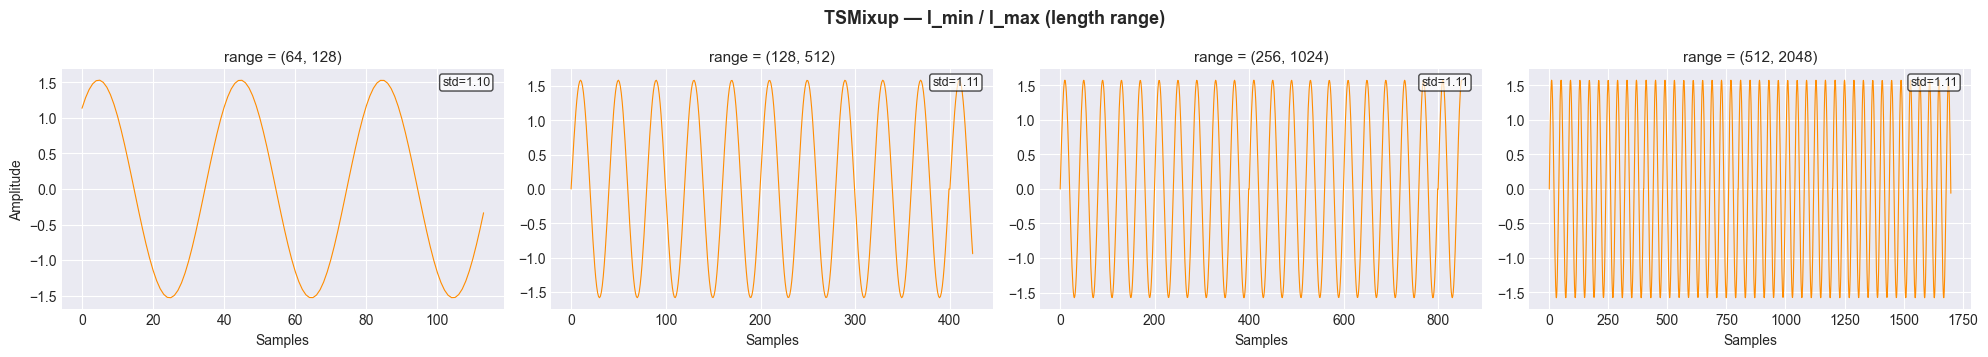

In [11]:
sweep(lambda p: TSMixupGenerator(K=3, alpha=1.5, l_min=p[0], l_max=p[1], seed=SEED),
      [(64,128),(128,512),(256,1024),(512,2048)],
      'TSMixup — l_min / l_max (length range)', 'range', color='darkorange')

**fs** — no effect on the base signal (sample-space). Shown on a time axis to confirm only the duration label changes.

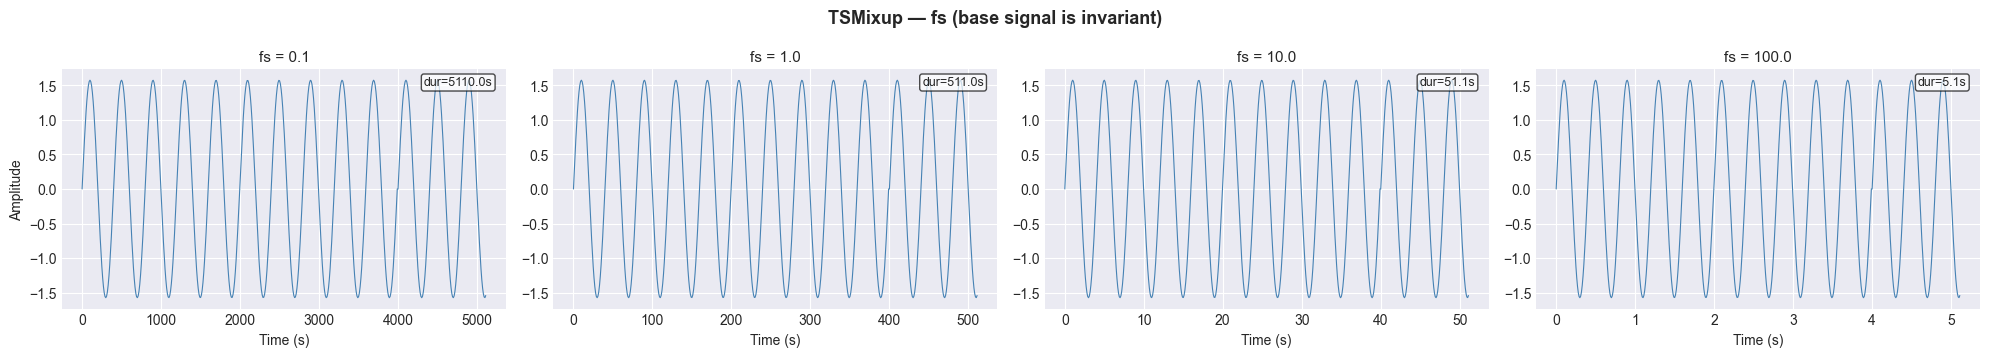

In [12]:
sweep(lambda fs: TSMixupGenerator(K=10, alpha=1.5, l_min=512, l_max=512, fs=fs, seed=SEED),
      [0.1, 1.0, 10.0, 100.0], 'TSMixup — fs (base signal is invariant)', 'fs', time_axis=True)

### Injection — same two modes as KernelSynth.

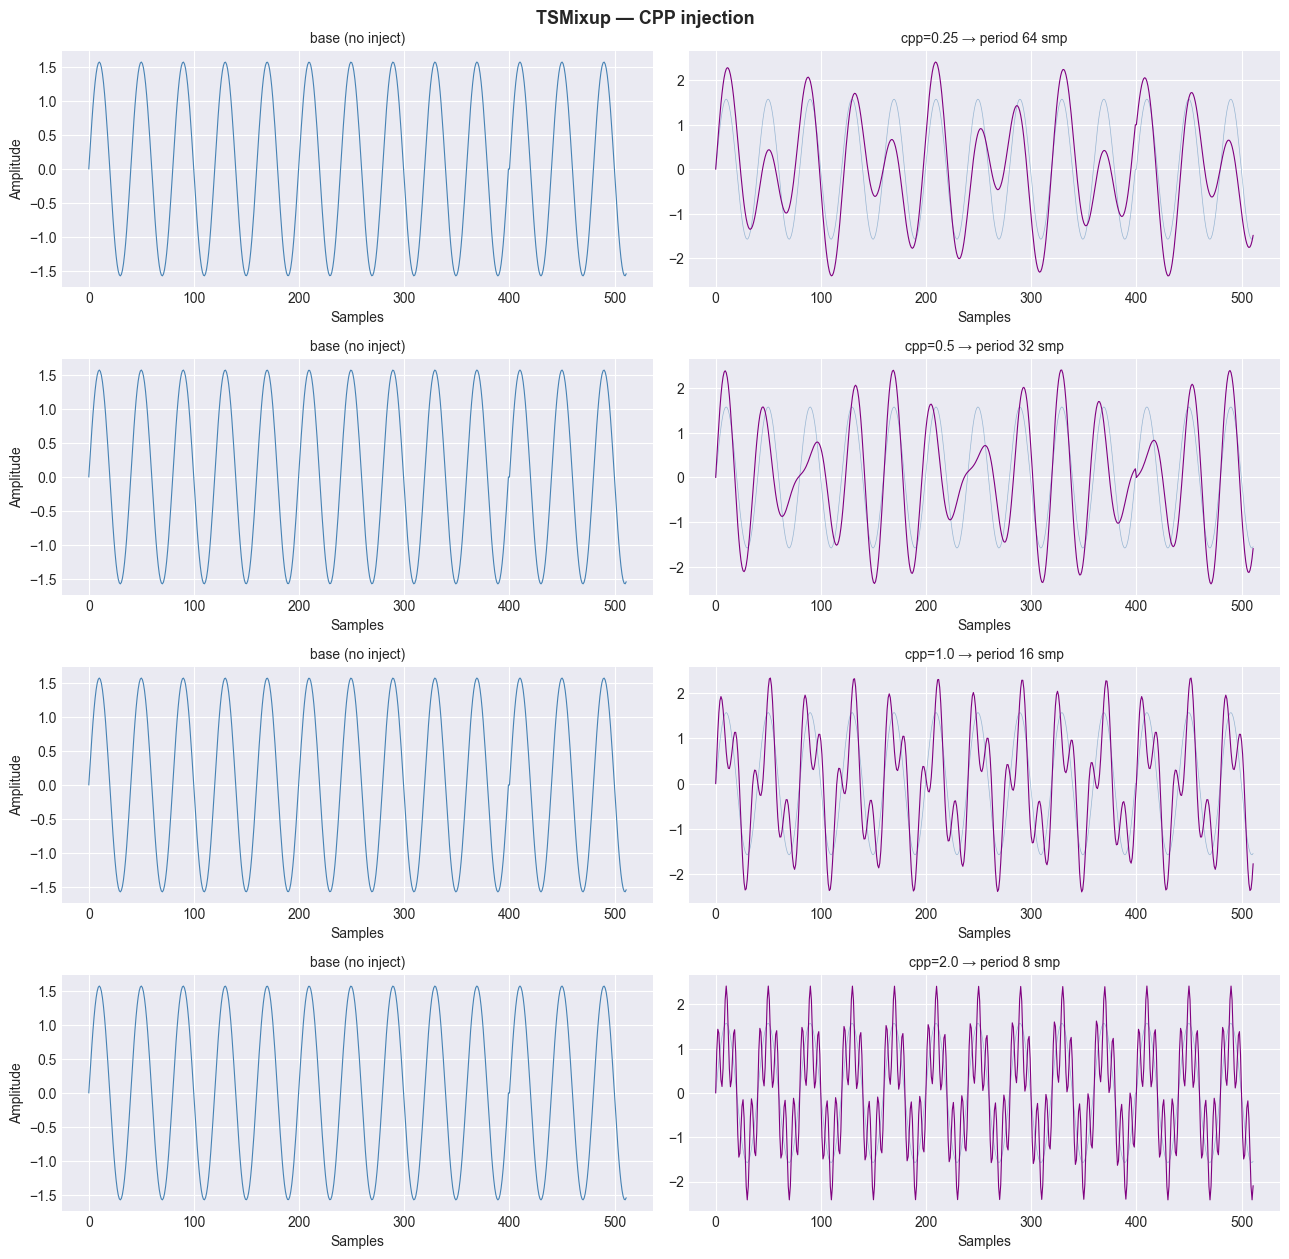

In [13]:
inject_compare(TSMixupGenerator, dict(K=3, alpha=1.5, l_min=512, l_max=512, fs=1.0),
               [0.25, 0.5, 1.0, 2.0], 'cpp', 'TSMixup — CPP injection')

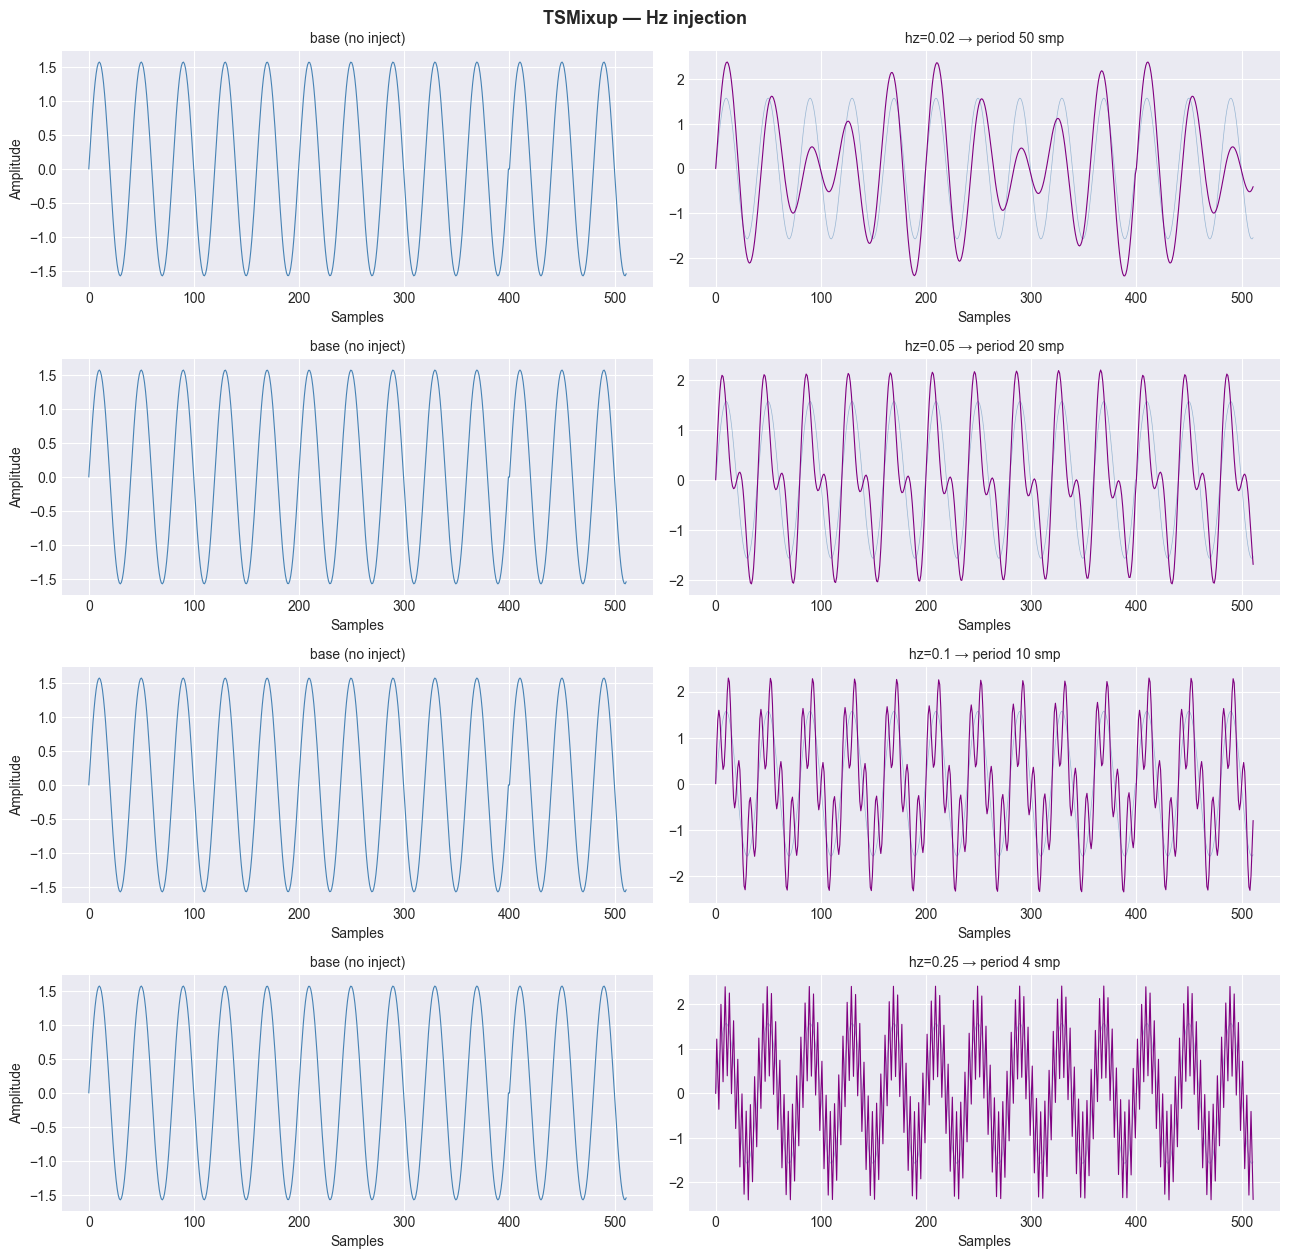

In [14]:
inject_compare(TSMixupGenerator, dict(K=10, alpha=1.5, l_min=512, l_max=512, fs=1.0),
               [0.02, 0.05, 0.1, 0.25], 'hz', 'TSMixup — Hz injection')